# Análise de mercado de games para campanha de 2017

Estudo de padrões de vendas no mercado de videogames para apoiar a definição de uma campanha comercial para 2017. A análise combina preparação de dados, exploração de tendências por plataforma, gênero e região, correlações e testes de hipótese.

**Ferramentas:** Python, pandas, seaborn e scipy.


## Visão geral dos dados


In [1]:
import pandas as pd
import seaborn as sns
from scipy import stats as st


In [2]:
df = pd.read_csv('data/games.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [3]:
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [4]:
df.sample(5, random_state = 29)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
1322,Mass Effect 2,PS3,2011.0,Role-Playing,0.78,0.45,0.03,0.19,94.0,8.5,M
13225,"Lupin III: Lupin ni wa Shi o, Zenigata ni wa K...",PS2,2007.0,Adventure,0.00,0.00,0.05,0.00,NaN,NaN,NaN
13101,Taiho Shichauzo!,PS,2001.0,Adventure,0.00,0.00,0.05,0.00,NaN,NaN,NaN
12243,Carol Vorderman's Sudoku,PSP,2006.0,Puzzle,0.05,0.00,0.00,0.01,72.0,tbd,E
8587,Fighters Destiny,N64,1998.0,Fighting,0.13,0.03,0.00,0.00,NaN,NaN,NaN


### Interpretação inicial dos dados fornecidos

* Ano em float, desnecessário
* Valores nulos mais concentrados em Critic_Score, User_Score e Rating.
* User_Score como object, melhor float. Obs.: tem cadastros como "tbd" na coluna, não compreensível ainda
* Nomes das colunas devem ser padronizados conforme PEP8 e para evitar erros futuros de digitação.


## Preparação dos dados


### Padronização dos nomes das colunas


In [5]:
df.columns = df.columns.str.lower()
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


### Conversão de tipos


#### Tratamento de `year_of_release`


In [7]:
# alterando tipo da coluna para Int64
df['year_of_release'] = df['year_of_release'].astype('Int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(5), object(5)
memory usage: 1.4+ MB


#### Tratamento de `user_score`


In [8]:
# trocando valores tbd por Nan
df['user_score'] = df['user_score'].replace('tbd', None)

# alterando tipo da coluna para float
df['user_score'] = df['user_score'].astype('float')

In [9]:
#checando string "tbd" em user_score
print(df[df['user_score'] == 'tbd'])

Empty DataFrame
Columns: [name, platform, year_of_release, genre, na_sales, eu_sales, jp_sales, other_sales, critic_score, user_score, rating]
Index: []


In [10]:
#checando valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       8760 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


### Cálculo de vendas totais


In [11]:
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [12]:
# criando coluna "total_sales"
df.insert(8, 'total_sales', df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales'])
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,82.54,76.0,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,35.52,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,32.77,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,31.38,NaN,NaN,NaN


### Correção de inconsistência temporal

Foi identificado um registro de Nintendo DS associado a 1985, incompatível com o período de atividade da plataforma. O ano é corrigido para 2004 antes das análises temporais.


In [13]:
df.loc[((df['platform'] == 'DS') & (df['year_of_release'] == 1985)), 'year_of_release'] = 2004

In [14]:
df[(df['platform'] == 'DS') & (df['year_of_release'] == 1985)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales,critic_score,user_score,rating


## Análise exploratória


### Veja quantos jogos foram lançados a cada ano
Os dados de cada período são significativos?


In [15]:
df_grouped_year = df.groupby('year_of_release').count()
df_grouped_year.info()
df_grouped_year['name'].head(37)

# Em tempo: considerando que um jogo de mesmo nome, 
## porém lançado em plataformas diferentes, conta como mais de um jogo

<class 'pandas.core.frame.DataFrame'>
Index: 37 entries, 1980 to 2016
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   name          37 non-null     int64
 1   platform      37 non-null     int64
 2   genre         37 non-null     int64
 3   na_sales      37 non-null     int64
 4   eu_sales      37 non-null     int64
 5   jp_sales      37 non-null     int64
 6   other_sales   37 non-null     int64
 7   total_sales   37 non-null     int64
 8   critic_score  37 non-null     int64
 9   user_score    37 non-null     int64
 10  rating        37 non-null     int64
dtypes: int64(11)
memory usage: 3.5+ KB


year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      13
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     763
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: name, dtype: int64

<AxesSubplot:title={'center':'Quantidade de jogos lançados por ano'}, xlabel='year_of_release'>

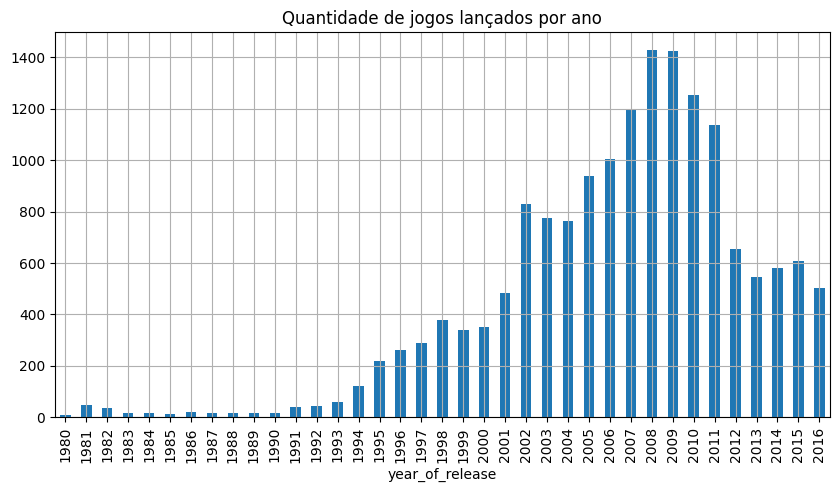

In [16]:
#visualizando dados

df_grouped_year['name'].plot(
    kind='bar',
    figsize=(10, 5),
    title='Quantidade de jogos lançados por ano',
    grid=True
)

#### Interpretação dos dados

**Os dados de cada período são significativos?**
Entendo que haja 4 períodos distintos, em uma primeira visualização sem método estatístico.

* 1980-1993: poucos jogos (menos de 100 por ano) foram lançados desde o ano inicial (1980) do conjunto de dados até por volta de 1993.
* 1994-2009: a partir de 1994, o lançamento de jogos começa a superar 100 anuais e entra numa tendência geral de crescimento até os auges de 2008 e 2009 (1427 e 1426 jogos anuais, respectivamente).
* 2010-2012: produção de jogos decai rapidamente
* 2013-2016:  após decaimento rápido entre 2010 e 2012, estabiliza em patamar médio de 500 a 700 anuais.
* Obs.: dados de 2016 podem estar incompletos

Assim, o primeiro período descrito parece menos relevante para análises sobre o mercado recente devido ao pequeno número de registros, enquanto os períodos posteriores apresentam volume de dados substancialmente maior.


### Veja como as vendas variaram de plataforma para plataforma. 

* Escolha as plataformas com as maiores vendas totais e construa uma distribuição com base nos dados para cada ano.
* Encontre as plataformas que costumavam ser populares, mas que agora não têm vendas.
* Quanto tempo leva para as novas plataformas aparecerem e as antigas desaparecerem?


#### Escolha as plataformas com as maiores vendas totais e construa uma distribuição com base nos dados para cada ano.


In [17]:
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,82.54,76.0,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,35.52,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,32.77,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,31.38,NaN,NaN,NaN


In [18]:
# agrupando por plataforma
df_groupedby_platform = df.groupby('platform')

# somando valores de vendas totais por plataforma
df_ts_sum = df_groupedby_platform['total_sales'].sum()

#do maior para menor
df_ts_sum_sorted = df_ts_sum.sort_values(ascending = False)
display(df_ts_sum_sorted)

#n de platformas
len(df_ts_sum_sorted)

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
3DS      259.00
XB       257.74
GB       255.46
NES      251.05
N64      218.68
SNES     200.04
GC       198.93
XOne     159.32
2600      96.98
WiiU      82.19
PSV       54.07
SAT       33.59
GEN       30.77
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64

31

In [19]:
df_ts_sum_sorted_big6 = df_ts_sum_sorted.head(6)
display(df_ts_sum_sorted_big6)


platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
Name: total_sales, dtype: float64

In [20]:
df_top6 = df[df['platform'].isin(df_ts_sum_sorted_big6.index)]
display(df_top6)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,82.54,76.0,8.0,E
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,35.52,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,32.77,80.0,8.0,E
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,29.80,89.0,8.5,E
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,28.91,58.0,6.6,E
...,...,...,...,...,...,...,...,...,...,...,...,...
16700,Mezase!! Tsuri Master DS,DS,2009,Sports,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN
16704,Plushees,DS,2008,Simulation,0.01,0.00,0.00,0.00,0.01,NaN,NaN,E
16709,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN


In [21]:

df_salesby_platform_year_big6 = df_top6.pivot_table(
    index='platform',      # valores que viram o ÍNDICE (linhas)
    columns='year_of_release', # valores que viram as COLUNAS
    values='total_sales',  # valores que serão agregados nas células
    aggfunc='sum'       # função de agregação aplicada
)

pd.set_option('display.max_columns', None)
display(df_salesby_platform_year_big6)

year_of_release,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
platform,,,,,,,,,,,,,,,,,,,,,,,
DS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.29,130.14,119.81,146.94,145.31,119.54,85.02,26.18,11.01,1.54,NaN,NaN,NaN
PS,6.03,35.96,94.7,136.17,169.49,144.53,96.37,35.59,6.67,2.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PS2,NaN,NaN,NaN,NaN,NaN,NaN,39.17,166.43,205.38,184.31,211.81,160.66,103.42,75.99,53.90,26.40,5.64,0.45,NaN,NaN,NaN,NaN,NaN
PS3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.96,73.19,118.52,130.93,142.17,156.78,107.36,113.25,47.76,16.82,3.60
Wii,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,137.15,152.77,171.32,206.97,127.95,59.65,21.71,8.59,3.75,1.14,0.18
X360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.25,51.62,95.41,135.26,120.29,170.03,143.84,99.74,88.58,34.74,11.96,1.52


In [22]:
# checando valor ilógico para DS em 1985
df[(df['platform'] == 'DS') & (df['year_of_release'] == 1985)]

# game foi lançado apenas em 2004, não pode aparecer em 1985 
# Retorno à etapa 2, modifico valor e rodo kernel de novo

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales,critic_score,user_score,rating


In [23]:
# verificando se há outros problemas semelhantes
df_teste = df.copy()
df_pivot_teste = df_teste.pivot_table(
    index='platform',      # valores que viram o ÍNDICE (linhas)
    columns='year_of_release', # valores que viram as COLUNAS
    values='total_sales',  # valores que serão agregados nas células
    aggfunc='sum'       # função de agregação aplicada
)

pd.set_option('display.max_columns', None)
display(df_pivot_teste)

year_of_release,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
platform,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2600,11.38,35.68,28.88,5.84,0.27,0.45,0.67,1.94,0.74,0.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3DO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.02,0.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3DS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.20,51.36,56.57,43.76,27.78,15.14
DC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.38,5.16,5.99,1.07,0.29,NaN,NaN,NaN,NaN,0.02,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.29,130.14,119.81,146.94,145.31,119.54,85.02,26.18,11.01,1.54,NaN,NaN,NaN
GB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.43,64.97,4.89,5.57,25.49,NaN,12.18,3.60,36.03,6.37,26.90,38.00,19.76,9.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GBA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07,61.53,74.16,56.67,77.91,33.86,5.28,3.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.34,51.81,50.61,28.82,27.62,11.26,0.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.60,4.33,12.64,3.07,8.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### Construção de distribuição


<AxesSubplot:xlabel='year_of_release'>

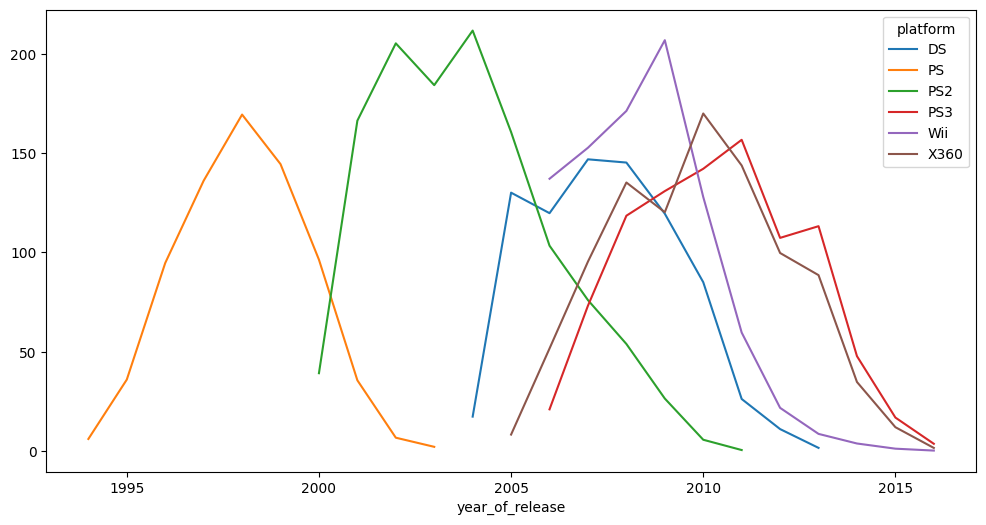

In [24]:
df_salesby_platform_year_big6.T.plot(figsize=(12, 6))

#### Encontre as plataformas que costumavam ser populares, mas que agora não têm vendas.


In [25]:
df_salesby_platform_year = df.pivot_table(
    index='platform',      # valores que viram o ÍNDICE (linhas)
    columns='year_of_release', # valores que viram as COLUNAS
    values='total_sales',  # valores que serão agregados nas células
    aggfunc='sum'       # função de agregação aplicada
)

display(df_salesby_platform_year)


year_of_release,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
platform,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2600,11.38,35.68,28.88,5.84,0.27,0.45,0.67,1.94,0.74,0.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3DO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.02,0.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3DS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.20,51.36,56.57,43.76,27.78,15.14
DC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.38,5.16,5.99,1.07,0.29,NaN,NaN,NaN,NaN,0.02,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.29,130.14,119.81,146.94,145.31,119.54,85.02,26.18,11.01,1.54,NaN,NaN,NaN
GB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.43,64.97,4.89,5.57,25.49,NaN,12.18,3.60,36.03,6.37,26.90,38.00,19.76,9.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GBA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07,61.53,74.16,56.67,77.91,33.86,5.28,3.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.34,51.81,50.61,28.82,27.62,11.26,0.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.60,4.33,12.64,3.07,8.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# 2014 - 2016 é o recorte definido para "agora", de forma que se possa captar anos recentes 
# em lugar de apenas 2016, que tem dados incompletos


# mostrando em código quais plataformas do top 6 não têm vendas em 2014-2016
df_salesby_platform_year_big6_nan14_16 = df_salesby_platform_year_big6[[2014, 2015, 2016]].isna()
display(df_salesby_platform_year_big6_nan14_16)

year_of_release,2014,2015,2016
platform,,,
DS,True,True,True
PS,True,True,True
PS2,True,True,True
PS3,False,False,False
Wii,False,False,False
X360,False,False,False


##### Conclusão preliminar
DS, PS e PS2 já foram populares (pois compõe o top 6 de total de vendas histórico), mas em anos recentes já não vendem mais.


#### Quanto tempo leva para as novas plataformas aparecerem e as antigas desaparecerem?


,year_min,year_max,duration
platform,,,
2600,1980,1989,10
3DO,1994,1995,2
3DS,2011,2016,6
DC,1998,2008,11
DS,2004,2013,10
GB,1988,2001,14
GBA,2000,2007,8
GC,2001,2007,7
GEN,1990,1994,5


<AxesSubplot:xlabel='platform'>

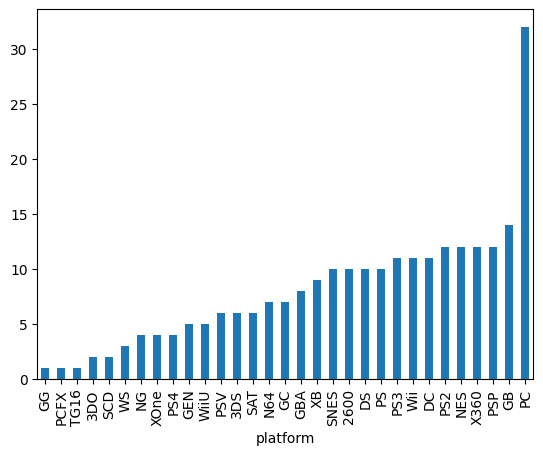

In [27]:
# agrupado por plataforma
df_groupedby_platform = df.groupby('platform')

# encontrando minimo, por plataforma, de year_of_release
df_year_min = df_groupedby_platform['year_of_release'].min()

# encontrando maximo, por plataforma, de year_of_release
df_year_max = df_groupedby_platform['year_of_release'].max()

#criando df comparativo
df_year_max_min = pd.DataFrame({
    'year_min': df_year_min,
    'year_max': df_year_max
})

#criando coluna com duração de cada plataforma
df_year_max_min['duration'] = (df_year_max_min['year_max'] - df_year_max_min['year_min'] + 1)
# o +1 entra para não eliminar o ano inicial da duração total

display(df_year_max_min)
df_year_max_min['duration'].sort_values().plot(kind='bar')

In [28]:
#verificando plataformas que estão com ciclo ativo em 2016

df_year_max2016 = df_year_max_min[df_year_max_min['year_max'] == 2016]
display(df_year_max2016)

,year_min,year_max,duration
platform,,,
3DS,2011,2016,6
PC,1985,2016,32
PS3,2006,2016,11
PS4,2013,2016,4
PSV,2011,2016,6
Wii,2006,2016,11
WiiU,2012,2016,5
X360,2005,2016,12
XOne,2013,2016,4


<AxesSubplot:xlabel='platform'>

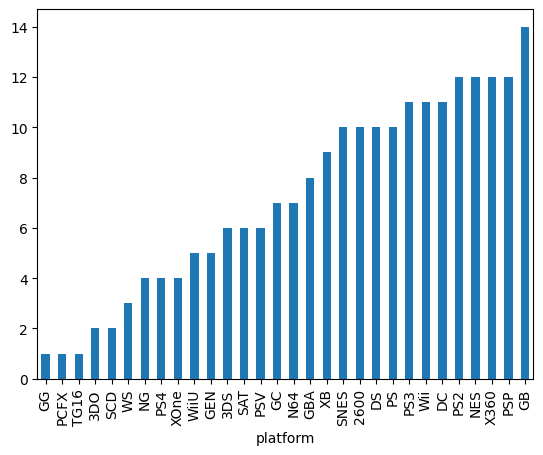

In [29]:
#tirando PC da análise

df_year_max_min_semPC = df_year_max_min.drop('PC')
df_year_max_min_semPC['duration'].sort_values().plot(kind='bar')

In [30]:
# retirando da análise plataformas que estão com ciclo ativo em 2016 (inclui retirada de PC)

df_year_without_max2016 = df_year_max_min[~(df_year_max_min['year_max'] == 2016)]
display(df_year_without_max2016)

,year_min,year_max,duration
platform,,,
2600,1980,1989,10
3DO,1994,1995,2
DC,1998,2008,11
DS,2004,2013,10
GB,1988,2001,14
GBA,2000,2007,8
GC,2001,2007,7
GEN,1990,1994,5
GG,1992,1992,1


In [31]:
#calculando diferentes tempos médios de duração

## todas plataformas
display(df_year_max_min['duration'].mean())
display(df_year_max_min['duration'].median())

## sem PC
display(df_year_max_min_semPC['duration'].mean())
display(df_year_max_min_semPC['duration'].median())

## sem PC e sem plataformas ativas em 2016
display(df_year_without_max2016['duration'].mean())
display(df_year_without_max2016['duration'].median())

8.0

7.0

7.2

7.0

7.136363636363637

7.5

##### Conclusão preliminar

Sem mais informações no pedido original de análise, optou-se por calcular médias e medianas para três combinações diferentes de duração de plataformas: completa, sem PC e sem PC nem plataformas ativas em 2016.

Motivos:
* PC é uma plataforma contínua, cuja duração é, por natureza, muito diferente das demais. Assim, entendeu-se ser importante avaliar o conjunto de dados sem esta plataforma
* Plataformas ainda tivas em 2016 podem ter durações maiores no futuro que são intrinsecamente desconhecidas. Por isso, também procurou-se visualizar as informações com essas plataformas retiradas.

**Conclui-se** que o ciclo de vida típico das plataformas fica em torno de 7 a 8 anos. Ao desconsiderar o PC, os valores ficam mais concentrados em aproximadamente 7 a 7,5 anos.


### Determine para qual período você deve pegar dados. 

Para fazer isso, olhe para suas respostas das perguntas anteriores. Os dados devem permitir que você construa um modelo para 2017.


In [32]:
# verificando novamente dados

## dados completos (em ordem decrescente de duração)
display(df_year_max_min.sort_values(by='duration', ascending=False))

###média e mediana dos dados completos
display(df_year_max_min['duration'].mean())
display(df_year_max_min['duration'].median())

,year_min,year_max,duration
platform,,,
PC,1985,2016,32
GB,1988,2001,14
NES,1983,1994,12
X360,2005,2016,12
PSP,2004,2015,12
PS2,2000,2011,12
DC,1998,2008,11
Wii,2006,2016,11
PS3,2006,2016,11


8.0

7.0

In [33]:
## dados apenas de plataformas que ainda estão vendendo em 2016 
# (decrescente por duração)
display(df_year_max2016.sort_values(by='year_min'))

###média e mediana dos dados de plataformas ainda vendendo em 2016
display(df_year_max2016['duration'].mean())
display(df_year_max2016['duration'].median())

,year_min,year_max,duration
platform,,,
PC,1985,2016,32
X360,2005,2016,12
PS3,2006,2016,11
Wii,2006,2016,11
3DS,2011,2016,6
PSV,2011,2016,6
WiiU,2012,2016,5
PS4,2013,2016,4
XOne,2013,2016,4


10.11111111111111

6.0

In [34]:
df_filtered_2009_2015 = df[
    (df['year_of_release'] >= 2009) &
    (df['year_of_release'] <= 2015)
].copy()

display(df_filtered_2009_2015.sort_values(by='year_of_release'))

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales,critic_score,user_score,rating
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,32.77,80.0,8.0,E
10485,Family Fun Football,Wii,2009,Sports,0.10,0.00,0.00,0.01,0.11,NaN,9.0,E
10504,Just In Time Translations,DS,2009,Misc,0.10,0.00,0.00,0.01,0.11,NaN,6.2,E
10511,WireWay,DS,2009,Adventure,0.10,0.00,0.00,0.01,0.11,62.0,7.6,E
10512,Astro Boy: The Video Game,DS,2009,Action,0.09,0.00,0.00,0.01,0.10,34.0,7.6,E
...,...,...,...,...,...,...,...,...,...,...,...,...
11872,Fairy Fencer F: Advent Dark Force,PS4,2015,Role-Playing,0.02,0.00,0.05,0.00,0.07,71.0,6.2,T
10643,Sword Art Online: Lost Song,PS3,2015,Role-Playing,0.00,0.00,0.10,0.00,0.10,NaN,NaN,NaN
1817,The Legend of Zelda: Tri Force Heroes,3DS,2015,Action,0.53,0.33,0.17,0.08,1.11,73.0,7.6,E
1026,The Order: 1886,PS4,2015,Shooter,0.61,0.78,0.06,0.27,1.72,63.0,6.6,M


### Trabalhar apenas com os dados que você decidiu que são relevantes

Optou-se por trabalhar com os dados de 2009 a 2015. Nas análises anteriores, a duração média das plataformas foi de 7 a 8 anos (puxada para cima pela plataforma PC, que não pode ser desprezada porque tem um ciclo distinto do usual) e a mediana de 7 anos. 

Assim, uma janela de sete anos permite observar aproximadamente um ciclo típico de mercado, ao mesmo tempo em que prioriza dados recentes para a construção de um modelo voltado a 2017.


**DataFrame filtrado**
df_filtered_2009_2015


### Quais plataformas estão liderando em vendas?


In [35]:
# plataformas líderes em vendas
df_filtered_2009_2015_platform = (
    df_filtered_2009_2015
    .groupby('platform')['total_sales']
    .sum()
)

display(df_filtered_2009_2015_platform.sort_values(ascending=False))

platform
PS3     715.07
X360    669.18
Wii     429.76
PS4     244.89
DS      243.29
3DS     242.67
PC      133.62
XOne    133.17
PSP     101.83
WiiU     77.59
PSV      49.56
PS2      32.49
Name: total_sales, dtype: float64

#### Quais estão crescendo ou diminuindo?


year_of_release,2009,2010,2011,2012,2013,2014,2015
platform,,,,,,,
3DS,NaN,NaN,63.20,51.36,56.57,43.76,27.78
DS,119.54,85.02,26.18,11.01,1.54,NaN,NaN
PC,16.91,24.28,35.03,23.22,12.38,13.28,8.52
PS2,26.40,5.64,0.45,NaN,NaN,NaN,NaN
PS3,130.93,142.17,156.78,107.36,113.25,47.76,16.82
PS4,NaN,NaN,NaN,NaN,25.99,100.00,118.90
PSP,37.78,35.04,17.82,7.69,3.14,0.24,0.12
PSV,NaN,NaN,4.63,16.19,10.59,11.90,6.25
Wii,206.97,127.95,59.65,21.71,8.59,3.75,1.14


<AxesSubplot:xlabel='year_of_release'>

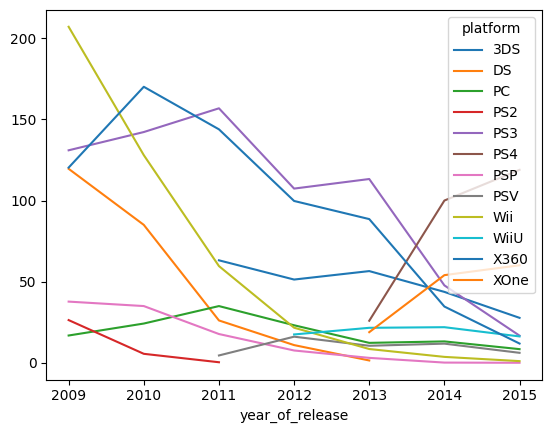

In [36]:
df_filtered_2009_2015_pivot = df_filtered_2009_2015.pivot_table(
    index='platform',      # valores que viram o ÍNDICE (linhas)
    columns='year_of_release', # valores que viram as COLUNAS
    values='total_sales',  # valores que serão agregados nas células
    aggfunc='sum'       # função de agregação aplicada
)

display(df_filtered_2009_2015_pivot)

df_filtered_2009_2015_pivot.T.plot()

##### Sobre o gráfico
O gráfico de linhas foi usado como visão geral, mas, devido à quantidade de plataformas e aos diferentes anos de entrada no mercado, mudarei a abordagem de análise para o problema em questão.


In [37]:
# verificando novamente tabela de vendas por ano por plataforma
display(df_filtered_2009_2015_pivot)

year_of_release,2009,2010,2011,2012,2013,2014,2015
platform,,,,,,,
3DS,NaN,NaN,63.20,51.36,56.57,43.76,27.78
DS,119.54,85.02,26.18,11.01,1.54,NaN,NaN
PC,16.91,24.28,35.03,23.22,12.38,13.28,8.52
PS2,26.40,5.64,0.45,NaN,NaN,NaN,NaN
PS3,130.93,142.17,156.78,107.36,113.25,47.76,16.82
PS4,NaN,NaN,NaN,NaN,25.99,100.00,118.90
PSP,37.78,35.04,17.82,7.69,3.14,0.24,0.12
PSV,NaN,NaN,4.63,16.19,10.59,11.90,6.25
Wii,206.97,127.95,59.65,21.71,8.59,3.75,1.14


#### Conclusão

* Para avaliar as tendências recentes, foram comparadas as vendas anuais das plataformas entre 2013 e 2015. 
* A análise considera como crescimento claro plataformas com aumento sucessivo das vendas ao longo do período e como queda clara aquelas com redução sucessiva. 
* Casos com oscilações e plataformas com aparente término do ciclo de vida são tratados separadamente.
* Dados de 2016 foram desconsiderados: por estarem incompletos, poderiam gerar distorções na análise.

##### Crescimento sustentado
* PS4 e XOne

##### Queda sustentada
* 3DS, PS3, PSP e X360

##### Oscilação
* PC, WiiU e PSV

##### Aparente término do ciclo de vida
* DS (sem vendas nos últimos 2 anos) e PS2 (sem vendas nos 3 anos)


#### Exercício livre

Abaixo, tentei criar códigos que confirmassem a visualização da tabela


In [38]:
# comparando em código crescimento sustentado
df_15_14 = df_filtered_2009_2015_pivot[2015] > df_filtered_2009_2015_pivot[2014]
df_14_13 = df_filtered_2009_2015_pivot[2014] > df_filtered_2009_2015_pivot[2013]
df_13_12 = df_filtered_2009_2015_pivot[2013] > df_filtered_2009_2015_pivot[2012]

##visualizando em código se houve crescimento sustentado
### de 2013 a 2015, ano a ano
df_crescimento_13_15 = df_15_14 & df_14_13
display(df_crescimento_13_15)


### de 2012 a 2015, ano a ano
df_crescimento_12_15 = df_15_14 & df_14_13 & df_13_12
display(df_crescimento_12_15)
#### percebo que série booleana dá False mesmo nas duas plataformas que tinham crescimento porque a comparação
#### é número absoluto com NaN, o que sempre é False

platform
3DS     False
DS      False
PC      False
PS2     False
PS3     False
PS4      True
PSP     False
PSV     False
Wii     False
WiiU    False
X360    False
XOne     True
dtype: bool

platform
3DS     False
DS      False
PC      False
PS2     False
PS3     False
PS4     False
PSP     False
PSV     False
Wii     False
WiiU    False
X360    False
XOne    False
dtype: bool

In [39]:
# comparando em código queda sustentada
df_15_14_queda = df_filtered_2009_2015_pivot[2015] < df_filtered_2009_2015_pivot[2014]
df_14_13_queda = df_filtered_2009_2015_pivot[2014] < df_filtered_2009_2015_pivot[2013]
df_13_12_queda = df_filtered_2009_2015_pivot[2013] < df_filtered_2009_2015_pivot[2012]

##visualizando em código se houve queda sustentada
### de 2013 a 2015, ano a ano
df_queda_13_15 = df_15_14_queda & df_14_13_queda
display(df_queda_13_15)


## de 2012 a 2015, ano a ano
df_queda_12_15 = df_15_14_queda & df_14_13_queda & df_13_12_queda
display(df_queda_12_15)

platform
3DS      True
DS      False
PC      False
PS2     False
PS3      True
PS4     False
PSP      True
PSV     False
Wii      True
WiiU    False
X360     True
XOne    False
dtype: bool

platform
3DS     False
DS      False
PC      False
PS2     False
PS3     False
PS4     False
PSP      True
PSV     False
Wii      True
WiiU    False
X360     True
XOne    False
dtype: bool

#### Conclusão do exercício livre

Os códigos propostos são mais limitados que a visualização da tabela. Problemas quando se compara números absolutos com Nan, bem como a captação de oscilações, são limitantes.


#### Selecione várias plataformas potencialmente lucrativas.


* Da análise realizada até então, selecionam-se apenas as plataformas **PS4,  XOne, PC e WiiU**. As duas primeiras são as únicas com tendência de crescimento sucessivo. Já WiiU oscila dentro dos 3 anos em análise, mas mantém vendas significativas em 2015, portanto não pode ser descartado. A plataforma **PC** é escolhida porque se mantém estável ao longo das décadas. 
* As demais já esgotaram ciclo de vida ou estão em claro processo de declínio.


### Construa um diagrama de caixa para as vendas globais de todos os jogos, divididos por plataforma


<AxesSubplot:xlabel='platform', ylabel='total_sales'>

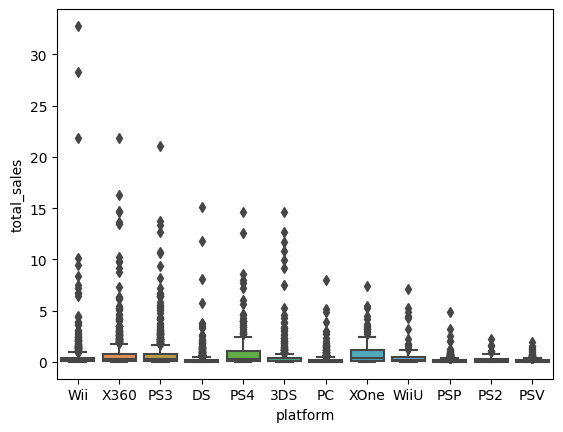

In [41]:
#display(df_filtered_2009_2015)

sns.boxplot(
    data=df_filtered_2009_2015,
    x='platform',
    y='total_sales'
)

####  As diferenças nas vendas são significativas?

* Sim.
* Wii, X360 e PS3 tem os outliers mais relevantes, o que demonstra que as plataformas têm os games de maior sucesso de vendas no período analisado.
* Visualmente, Wii, X360, PS3, DS, PS4 e 3DS possuem uma quantidade maior de outliers que romperam a casa dos 10 milhões em vendas que as demais plataformas. Isso sinaliza que as seis citadas lançam sucessos de vendas mais estrondosos que as outras seis.
* Porém, visualmente o gráfico não permite concluir que as seis citadas lançam mais quantidade de sucessos de vendas, pois há uma aglutinação visual de outliers mais próximos ao último fio de bigode em todas as plataformas, o que impede uma quantificação de outliers.


#### E quanto às vendas médias em várias plataformas?


In [42]:
# Vendas médias de JOGOS POR PLATAFORMA
## ou seja: quanto vendeu, em média, cada jogo daquela plataforma, no período 2009-2015?

df_filtered_2009_2015_filteredby_platform_mean = df_filtered_2009_2015.groupby("platform")['total_sales'].mean()
display(df_filtered_2009_2015_filteredby_platform_mean.sort_values(ascending=False))

platform
PS4     1.074079
XOne    0.832312
X360    0.797592
PS3     0.705893
WiiU    0.583383
Wii     0.555245
3DS     0.520751
DS      0.267352
PC      0.251165
PS2     0.230426
PSP     0.154054
PSV     0.144070
Name: total_sales, dtype: float64

##### Análise complementar
Não ficou claro que média era objeto do pedido. Portanto, faço também a proposta abaixo


In [43]:
# Média anual de vendas de jogos de cada PLATAFORMA
## ou seja: quanto, em média, cada plataforma vendeu, por ano com vendas ativas (nunique()), no período 2009-2015

df_filtered_2009_2015_ts = df_filtered_2009_2015.groupby("platform")['total_sales'].sum() 
df_filtered_2009_2015_years_with_sales = df_filtered_2009_2015.groupby("platform")['year_of_release'].nunique()

df_global_mean_byplatform = df_filtered_2009_2015_ts / df_filtered_2009_2015_years_with_sales

display(df_global_mean_byplatform.sort_values(ascending=False))

platform
PS3     102.152857
X360     95.597143
PS4      81.630000
Wii      61.394286
DS       48.658000
3DS      48.534000
XOne     44.390000
WiiU     19.397500
PC       19.088571
PSP      14.547143
PS2      10.830000
PSV       9.912000
dtype: float64

In [44]:
df_compare_means = pd.DataFrame({
    'média de vendas de jogos por plataforma': df_filtered_2009_2015_filteredby_platform_mean,
    'média de vendas anual da plataforma': df_global_mean_byplatform,
    })

display(df_compare_means)
# não funciona para comparar rankings

,média de vendas de jogos por plataforma,média de vendas anual da plataforma
platform,,
3DS,0.520751,48.534000
DS,0.267352,48.658000
PC,0.251165,19.088571
PS2,0.230426,10.830000
PS3,0.705893,102.152857
PS4,1.074079,81.630000
PSP,0.154054,14.547143
PSV,0.144070,9.912000
Wii,0.555245,61.394286


#### Descreva suas descobertas.


* PS4 e XOne são as plataformas com tendência de crescimento de vendas nos últimos anos (2013-2015).
* WiiU é uma plataforma que parece estar em baixa, mas ainda vende bem em 2015.
* PC não teve ciclo de vida encerrado em décadas.
* PS4, XOne, X360 e PS3, nessa ordem, são as plataformas cujos jogos lançados mais rendem, em média, para as empresas. As duas primeiras são também as únicas duas plataformas com tendência de crescimento claro nos últimos anos.
* Como curiosidade, PS3, X360, PS4 e Wii são as plataformas que tiveram maior renda média anual no período analisado. E Wii, no período analisado, é a plataforma que lançou os maiores sucessos de vendas dentre todas.


### Veja como as avaliações de usuários e profissionais afetam as vendas de uma das plataformas populares (você escolhe).
* Construa um gráfico de dispersão
* Calcule a correlação entre avaliações e vendas.


In [45]:
# visualizando dados gerais
display(df_filtered_2009_2015)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales,critic_score,user_score,rating
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,32.77,80.0,8.0,E
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,28.32,87.0,8.4,E
14,Kinect Adventures!,X360,2010,Misc,15.00,4.89,0.24,1.69,21.82,61.0,6.3,E
15,Wii Fit Plus,Wii,2009,Sports,9.01,8.49,2.53,1.77,21.80,80.0,7.4,E
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,21.05,97.0,8.2,M
...,...,...,...,...,...,...,...,...,...,...,...,...
16696,Breach,PC,2011,Shooter,0.01,0.00,0.00,0.00,0.01,61.0,5.8,T
16700,Mezase!! Tsuri Master DS,DS,2009,Sports,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN
16702,STORM: Frontline Nation,PC,2011,Strategy,0.00,0.01,0.00,0.00,0.01,60.0,7.2,E10+
16705,15 Days,PC,2009,Adventure,0.00,0.01,0.00,0.00,0.01,63.0,5.8,NaN


In [46]:
# selecionando apenas jogos de PS4

df_filtered_2009_2015_PS4 = df_filtered_2009_2015[
    df_filtered_2009_2015['platform'] == 'PS4'
]

display(df_filtered_2009_2015_PS4)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales,critic_score,user_score,rating
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,14.63,NaN,NaN,NaN
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,12.62,97.0,8.3,M
77,FIFA 16,PS4,2015,Sports,1.12,6.12,0.06,1.28,8.58,82.0,4.3,E
87,Star Wars Battlefront (2015),PS4,2015,Shooter,2.99,3.49,0.22,1.28,7.98,NaN,NaN,NaN
92,Call of Duty: Advanced Warfare,PS4,2014,Shooter,2.81,3.48,0.14,1.23,7.66,83.0,5.7,M
...,...,...,...,...,...,...,...,...,...,...,...,...
15556,Natsuiro High School: Seishun Hakusho,PS4,2015,Action,0.00,0.00,0.02,0.00,0.02,NaN,NaN,NaN
15762,Rabbids Invasion: The Interactive TV Show,PS4,2014,Misc,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN
15943,Professional Farmer 2016,PS4,2015,Action,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN
16158,Raven's Cry,PS4,2015,Role-Playing,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN


<AxesSubplot:xlabel='critic_score', ylabel='user_score'>

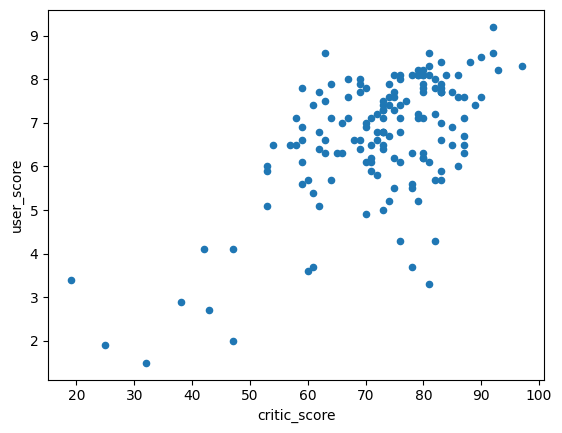

In [47]:
# gráfico de dispersão para visualizar
df_filtered_2009_2015_PS4.plot(x='critic_score', y='user_score', kind='scatter')

<AxesSubplot:xlabel='critic_score', ylabel='total_sales'>

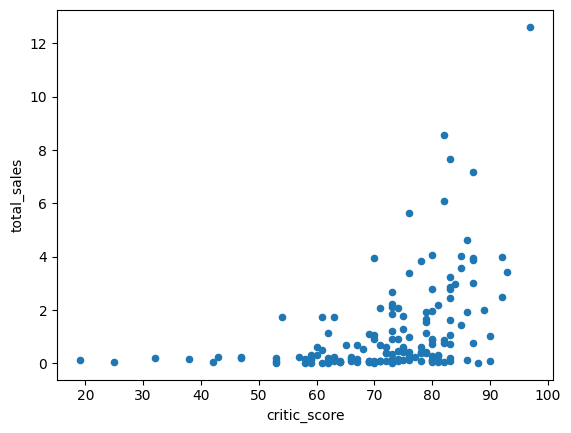

In [48]:
# gráfico de dispersão critic_score x total_sales
df_filtered_2009_2015_PS4.plot(x='critic_score', y='total_sales', kind='scatter')

<AxesSubplot:xlabel='user_score', ylabel='total_sales'>

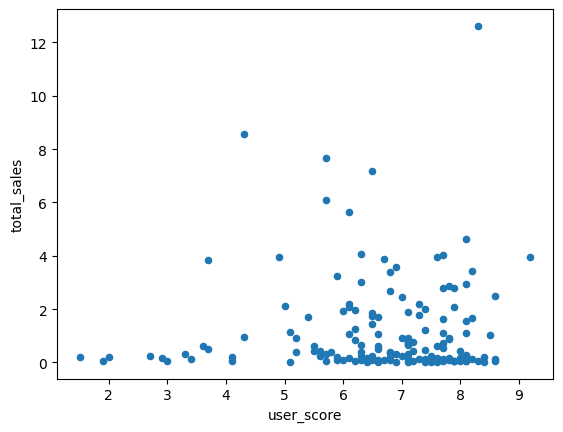

In [49]:
# gráfico de dispersão user_score x total_sales
df_filtered_2009_2015_PS4.plot(x='user_score', y='total_sales', kind='scatter')

In [50]:
# cálculo de correlação critic_score x total_sales
display(df_filtered_2009_2015_PS4['total_sales'].corr(df_filtered_2009_2015_PS4['critic_score']))

0.4318482049982005

In [51]:
# cálculo de correlação user_score x total_sales
display(df_filtered_2009_2015_PS4['total_sales'].corr(df_filtered_2009_2015_PS4['user_score']))

0.024230832360622553

**Por curiosidade, vou verificar se há valores nulos nas colunas em avaliação**


In [52]:
# verificando n de valores nulos na coluna user_score
df_filtered_2009_2015_PS4['user_score'].isna().sum()

72

In [53]:
# verificando n de valores nulos na coluna critic_score
df_filtered_2009_2015_PS4['critic_score'].isna().sum()

74

In [54]:
#verificando se valores batem com pares de valores nulos
df_visual = df_filtered_2009_2015_PS4[df_filtered_2009_2015_PS4['critic_score'].isna() & df_filtered_2009_2015_PS4['user_score'].isna()]
display(df_visual)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales,critic_score,user_score,rating
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,14.63,NaN,NaN,NaN
87,Star Wars Battlefront (2015),PS4,2015,Shooter,2.99,3.49,0.22,1.28,7.98,NaN,NaN,NaN
225,The Last of Us,PS4,2014,Action,1.88,2.00,0.07,0.77,4.72,NaN,NaN,NaN
261,Minecraft,PS4,2014,Misc,1.48,2.02,0.14,0.68,4.32,NaN,NaN,NaN
639,Need for Speed (2015),PS4,2015,Racing,0.50,1.50,0.05,0.37,2.42,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
15556,Natsuiro High School: Seishun Hakusho,PS4,2015,Action,0.00,0.00,0.02,0.00,0.02,NaN,NaN,NaN
15762,Rabbids Invasion: The Interactive TV Show,PS4,2014,Misc,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN
15943,Professional Farmer 2016,PS4,2015,Action,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN
16158,Raven's Cry,PS4,2015,Role-Playing,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN


In [55]:
#verificando par (número em critic_score) e (nulo em user_score)
df_visual_1 = df_filtered_2009_2015_PS4[(df_filtered_2009_2015_PS4['critic_score'] >= 0) & (df_filtered_2009_2015_PS4['user_score'].isna())]
display(df_visual_1)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales,critic_score,user_score,rating
8242,MotoGP 15,PS4,2015,Racing,0.0,0.12,0.03,0.02,0.17,66.0,NaN,NaN


In [56]:
#verificando par (nulo em critic_score) e (número em user_score)
df_visual_2 = df_filtered_2009_2015_PS4[(df_filtered_2009_2015_PS4['critic_score'].isna()) & (df_filtered_2009_2015_PS4['user_score'] >= 0)]
display(df_visual_2)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales,critic_score,user_score,rating
8190,Back to the Future: The Game,PS4,2015,Adventure,0.1,0.05,0.0,0.03,0.18,NaN,7.1,T
12817,Handball 16,PS4,2015,Sports,0.0,0.05,0.0,0.01,0.06,NaN,3.0,E
15085,Rugby League Live 3,PS4,2015,Action,0.0,0.02,0.0,0.00,0.02,NaN,7.6,E


**Concluo que o número de nulos é irrelevante para a análise de correlação e prossigo**


#### Conclusão preliminar
Não existe correlação entre avaliações de usuários e vendas totais.
Existe uma pequena correlação positiva entre avaliações os críticos e vendas totais


### Tendo suas conclusões em mente, compare as vendas dos mesmos jogos em outras plataformas.


In [57]:
# comparando vendas dos mesmos jogos em outras plataformas

df_filtered_2009_2015_PS4games_in_other_platforms = (df_filtered_2009_2015[df_filtered_2009_2015['name'].isin(df_filtered_2009_2015_PS4['name'])])

df_filtered_2009_2015_PS4games_in_other_platforms_pivot = (df_filtered_2009_2015_PS4games_in_other_platforms.pivot_table(index='name', columns='platform', values='total_sales', aggfunc='sum'))

display(df_filtered_2009_2015_PS4games_in_other_platforms_pivot)

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
name,,,,,,,,,,,
Adventure Time: Finn & Jake Investigations,0.09,NaN,NaN,0.08,0.10,NaN,NaN,NaN,0.05,0.09,0.05
Akiba's Trip: Undead & Undressed,NaN,NaN,NaN,0.11,0.11,NaN,0.15,NaN,NaN,NaN,NaN
Alien: Isolation,NaN,NaN,0.15,0.33,1.12,NaN,NaN,NaN,NaN,0.27,0.50
Angry Birds Star Wars,0.33,NaN,NaN,0.29,0.22,NaN,0.08,0.26,0.10,0.28,0.17
Arcania: Gothic 4,NaN,NaN,0.19,NaN,0.05,NaN,NaN,NaN,NaN,0.10,NaN
...,...,...,...,...,...,...,...,...,...,...,...
Yakuza Zero: The Place of Oath,NaN,NaN,NaN,0.25,0.17,NaN,NaN,NaN,NaN,NaN,NaN
Yakuza: Ishin,NaN,NaN,NaN,0.26,0.15,NaN,NaN,NaN,NaN,NaN,NaN
Yoru no Nai Kuni,NaN,NaN,NaN,0.05,0.08,NaN,0.08,NaN,NaN,NaN,NaN


In [58]:
display(df_filtered_2009_2015_PS4games_in_other_platforms_pivot.sort_values('PS4', ascending=False).head(30))

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
name,,,,,,,,,,,
Call of Duty: Black Ops 3,NaN,NaN,0.26,1.69,14.63,NaN,NaN,NaN,NaN,1.70,7.39
Grand Theft Auto V,NaN,NaN,1.17,21.05,12.62,NaN,NaN,NaN,NaN,16.27,5.47
FIFA 16,NaN,NaN,0.20,2.70,8.58,NaN,NaN,NaN,NaN,1.57,3.25
Star Wars Battlefront (2015),NaN,NaN,0.55,NaN,7.98,NaN,NaN,NaN,NaN,NaN,3.66
Call of Duty: Advanced Warfare,NaN,NaN,0.41,4.36,7.66,NaN,NaN,NaN,NaN,4.28,5.26
Fallout 4,NaN,NaN,1.28,NaN,7.17,NaN,NaN,NaN,NaN,NaN,4.22
FIFA 15,0.46,NaN,0.29,4.28,6.08,NaN,0.60,0.56,NaN,2.92,2.18
Destiny,NaN,NaN,NaN,1.61,5.64,NaN,NaN,NaN,NaN,1.92,3.37
The Last of Us,NaN,NaN,NaN,5.86,4.72,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
#comparando PS4 com as plataformas mais relevantes escolhidas: Xone
df_PS4_XOne = (df_filtered_2009_2015_PS4games_in_other_platforms_pivot
    [df_filtered_2009_2015_PS4games_in_other_platforms_pivot['PS4'] > df_filtered_2009_2015_PS4games_in_other_platforms_pivot['XOne']])
display(df_PS4_XOne)

df_PS4_XOne = (df_filtered_2009_2015_PS4games_in_other_platforms_pivot
    [df_filtered_2009_2015_PS4games_in_other_platforms_pivot['PS4'] < df_filtered_2009_2015_PS4games_in_other_platforms_pivot['XOne']])
display(df_PS4_XOne)

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
name,,,,,,,,,,,
Adventure Time: Finn & Jake Investigations,0.09,NaN,NaN,0.08,0.10,NaN,NaN,NaN,0.05,0.09,0.05
Alien: Isolation,NaN,NaN,0.15,0.33,1.12,NaN,NaN,NaN,NaN,0.27,0.50
Angry Birds Star Wars,0.33,NaN,NaN,0.29,0.22,NaN,0.08,0.26,0.10,0.28,0.17
Assassin's Creed IV: Black Flag,NaN,NaN,0.65,3.71,2.86,NaN,NaN,NaN,0.29,3.31,2.24
Assassin's Creed Syndicate,NaN,NaN,0.22,NaN,3.39,NaN,NaN,NaN,NaN,NaN,1.29
...,...,...,...,...,...,...,...,...,...,...,...
Wasteland 2,NaN,NaN,0.10,NaN,0.12,NaN,NaN,NaN,NaN,NaN,0.06
Watch Dogs,NaN,NaN,0.44,1.74,4.05,NaN,NaN,NaN,0.13,1.25,1.57
Wolfenstein: The New Order,NaN,NaN,0.45,0.44,1.54,NaN,NaN,NaN,NaN,0.38,0.68


platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
name,,,,,,,,,,,
Just Dance 2014,NaN,NaN,NaN,0.37,0.42,NaN,NaN,3.58,0.59,0.99,0.45
Just Dance 2015,NaN,NaN,NaN,0.25,0.39,NaN,NaN,2.01,0.73,0.61,0.53
Plants vs. Zombies: Garden Warfare,NaN,NaN,0.02,0.66,0.61,NaN,NaN,NaN,NaN,1.07,0.68
Rock Band 4,NaN,NaN,NaN,NaN,0.38,NaN,NaN,NaN,NaN,NaN,0.47


In [60]:
#comparando PS4 com as plataformas mais relevantes escolhidas: WiiU
df_PS4_WiiU = (df_filtered_2009_2015_PS4games_in_other_platforms_pivot
    [df_filtered_2009_2015_PS4games_in_other_platforms_pivot['PS4'] > df_filtered_2009_2015_PS4games_in_other_platforms_pivot['WiiU']])
display(df_PS4_WiiU)
display(df_PS4_WiiU.shape)

df_PS4_WiiU = (df_filtered_2009_2015_PS4games_in_other_platforms_pivot
    [df_filtered_2009_2015_PS4games_in_other_platforms_pivot['PS4'] < df_filtered_2009_2015_PS4games_in_other_platforms_pivot['WiiU']])
display(df_PS4_WiiU)
df_PS4_WiiU.shape

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
name,,,,,,,,,,,
Adventure Time: Finn & Jake Investigations,0.09,NaN,NaN,0.08,0.10,NaN,NaN,NaN,0.05,0.09,0.05
Angry Birds Star Wars,0.33,NaN,NaN,0.29,0.22,NaN,0.08,0.26,0.10,0.28,0.17
Assassin's Creed IV: Black Flag,NaN,NaN,0.65,3.71,2.86,NaN,NaN,NaN,0.29,3.31,2.24
Call of Duty: Ghosts,NaN,NaN,0.69,9.36,3.83,NaN,NaN,NaN,0.35,10.24,2.92
Darksiders II,NaN,NaN,0.15,0.85,0.23,NaN,NaN,NaN,0.15,0.79,0.07
Disney Infinity 3.0,NaN,NaN,NaN,0.44,0.73,NaN,NaN,NaN,0.46,0.39,0.34
Guitar Hero Live,NaN,NaN,NaN,0.27,0.86,NaN,NaN,NaN,0.19,0.23,0.55
Injustice: Gods Among Us,NaN,NaN,NaN,1.19,0.92,NaN,0.12,NaN,0.19,1.38,NaN
LEGO Dimensions,NaN,NaN,NaN,0.56,0.73,NaN,NaN,NaN,0.53,0.53,0.41


(20, 11)

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
name,,,,,,,,,,,
Disney Infinity 2.0: Marvel Super Heroes,NaN,NaN,NaN,0.95,0.62,NaN,0.06,NaN,0.65,1.08,0.44
Just Dance 2014,NaN,NaN,NaN,0.37,0.42,NaN,NaN,3.58,0.59,0.99,0.45
Just Dance 2015,NaN,NaN,NaN,0.25,0.39,NaN,NaN,2.01,0.73,0.61,0.53
Just Dance 2016,NaN,NaN,NaN,0.19,0.36,NaN,NaN,0.95,0.57,0.31,0.32
Shovel Knight,0.15,NaN,NaN,NaN,0.07,NaN,NaN,NaN,0.10,NaN,NaN
Skylanders SWAP Force,0.24,NaN,NaN,1.02,0.38,NaN,NaN,2.15,0.58,1.32,0.31
Skylanders: SuperChargers,0.12,NaN,NaN,0.37,0.30,NaN,NaN,0.15,0.48,0.42,0.24
Skylanders: Trap Team,0.28,NaN,NaN,0.67,0.44,NaN,NaN,0.95,0.70,0.89,0.37


(8, 11)

In [61]:
#comparando PS4 com as plataformas mais relevantes escolhidas: PC
df_PS4_PC = (df_filtered_2009_2015_PS4games_in_other_platforms_pivot
    [df_filtered_2009_2015_PS4games_in_other_platforms_pivot['PS4'] > df_filtered_2009_2015_PS4games_in_other_platforms_pivot['PC']])
display(df_PS4_PC)

df_PS4_PC = (df_filtered_2009_2015_PS4games_in_other_platforms_pivot
    [df_filtered_2009_2015_PS4games_in_other_platforms_pivot['PS4'] < df_filtered_2009_2015_PS4games_in_other_platforms_pivot['PC']])
display(df_PS4_PC)

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
name,,,,,,,,,,,
Alien: Isolation,NaN,NaN,0.15,0.33,1.12,NaN,NaN,NaN,NaN,0.27,0.50
Assassin's Creed IV: Black Flag,NaN,NaN,0.65,3.71,2.86,NaN,NaN,NaN,0.29,3.31,2.24
Assassin's Creed Syndicate,NaN,NaN,0.22,NaN,3.39,NaN,NaN,NaN,NaN,NaN,1.29
Assassin's Creed: Unity,NaN,NaN,0.55,NaN,3.96,NaN,NaN,NaN,NaN,NaN,3.50
Batman: Arkham Knight,NaN,NaN,0.13,NaN,3.96,NaN,NaN,NaN,NaN,NaN,1.49
...,...,...,...,...,...,...,...,...,...,...,...
Tropico 5,NaN,NaN,0.12,NaN,0.32,NaN,NaN,NaN,NaN,0.05,NaN
Wasteland 2,NaN,NaN,0.10,NaN,0.12,NaN,NaN,NaN,NaN,NaN,0.06
Watch Dogs,NaN,NaN,0.44,1.74,4.05,NaN,NaN,NaN,0.13,1.25,1.57


platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
name,,,,,,,,,,,
Arcania: Gothic 4,NaN,NaN,0.19,NaN,0.05,NaN,NaN,NaN,NaN,0.10,NaN
Diablo III,NaN,NaN,5.14,1.91,1.83,NaN,NaN,NaN,NaN,1.41,0.66
Dishonored,NaN,NaN,0.51,1.53,0.40,NaN,NaN,NaN,NaN,1.71,0.15
Farming Simulator 2015,NaN,NaN,1.19,0.37,0.36,NaN,NaN,NaN,NaN,0.36,0.20
Final Fantasy XIV: A Realm Reborn,NaN,NaN,1.53,1.08,0.75,NaN,NaN,NaN,NaN,NaN,NaN
Risen 3: Titan Lords,NaN,NaN,0.08,0.08,0.06,NaN,NaN,NaN,NaN,0.06,NaN
Rocksmith 2014,NaN,NaN,0.66,0.98,0.63,NaN,NaN,NaN,NaN,0.94,0.41
Terraria,NaN,NaN,0.14,0.41,0.07,NaN,0.1,NaN,NaN,0.68,0.04


##### Conclusão preliminar

* Jogos em PS4 vendem consistentemente mais do que quando também são lançados por outra plataforma.
* No recorte em análise, vendem mais do que os mesmos jogos para XOne e para PC.
* Dado a ter atenção: há poucos jogos lançados tanto para PS4 quanto para WiiU, plataforma que foi mantida, nesta análise, como potencialmente relevante, ainda que suas vendas demonstrem oscilação, possível tendência de queda e números mais baixos que PS4 e Xone. E dentro do recorte de poucos jogos lançados para ambas, 26 jogos para PS4 venderam mais, e 11 para WiiU venderam mais, mostrando proximidade de desempenho.
* Na comparação de PS4 com a plataforma que parece ser sua principal concorrente, a XOne: 202 jogos lançados para PS4 e XOne venderam mais no PS4, e apenas 7 venderam mais no XOne.


### Dê uma olhada na distribuição geral de jogos por gênero. 
* O que podemos dizer sobre os gêneros mais lucrativos? 
* Você pode generalizar sobre gêneros com vendas altas e baixas?


In [62]:
# distribuição geral de jogos por gênero
##gêneros mais lucrativos
## generalizações sobre gêneros mais ou menos lucrativos

series_filtered_2009_2015_tsbygenre = (df_filtered_2009_2015.groupby('genre')['total_sales'].sum().sort_values(ascending=False))

In [63]:
# distribuição geral de jogos por gênero na coluna sales_by_gender
# por plataforma

df_filtered_2009_2015_genre_orderedbyts = (
    df_filtered_2009_2015.pivot_table(
        index='genre',
        columns='platform',
        values='total_sales',
        aggfunc='sum'
    )
)

df_filtered_2009_2015_genre_orderedbyts['sales_by_gender'] = (
    series_filtered_2009_2015_tsbygenre
)

display(
    df_filtered_2009_2015_genre_orderedbyts
    .sort_values(by='sales_by_gender', ascending=False)
)

platform,3DS,DS,PC,PS2,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne,sales_by_gender
genre,,,,,,,,,,,,,
Action,52.69,55.08,21.96,6.06,241.29,81.25,23.78,15.15,61.31,17.27,171.92,32.91,780.67
Shooter,1.22,2.61,25.12,0.71,150.87,64.37,3.06,3.88,10.90,5.64,193.79,48.64,510.81
Sports,6.15,9.72,7.12,10.72,103.47,41.03,13.35,3.98,124.61,3.16,98.41,20.55,442.27
Role-Playing,75.84,54.95,28.96,0.43,61.37,23.01,24.24,10.94,9.05,2.47,43.92,9.23,344.41
Misc,10.49,31.65,0.99,5.70,31.90,7.59,5.35,4.22,120.65,11.69,70.19,7.35,307.77
Platform,32.23,8.20,0.34,1.38,15.32,5.53,3.73,2.56,60.67,21.31,5.10,0.65,157.02
Racing,14.87,6.04,2.86,1.43,43.16,10.95,7.44,2.51,11.66,7.87,36.48,8.31,153.58
Fighting,10.53,2.18,0.08,2.32,40.02,5.91,7.03,2.50,3.82,5.26,27.29,2.08,109.02
Simulation,26.72,22.34,23.65,2.26,7.84,0.68,1.71,0.07,8.63,0.20,8.12,0.56,102.78


<AxesSubplot:xlabel='genre'>

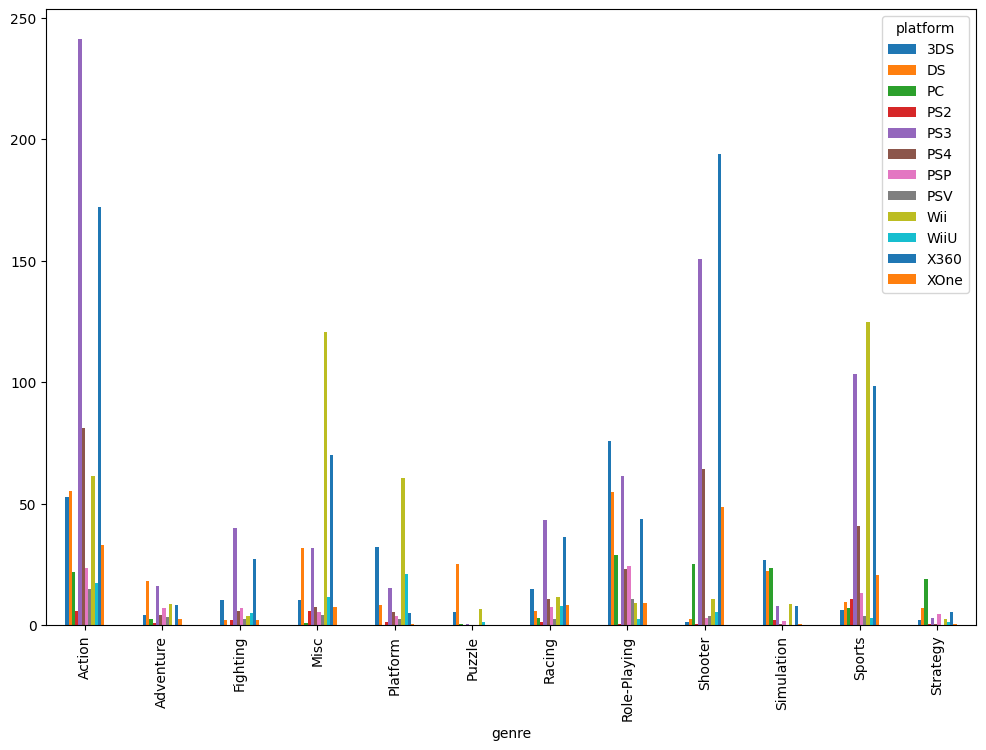

In [64]:
# visualizando vendas por gênero em cada plataforma

df_filtered_2009_2015_genre_orderedbyts.loc[:, '3DS':'XOne'].plot(kind='bar',figsize=(12, 8))

<AxesSubplot:xlabel='genre'>

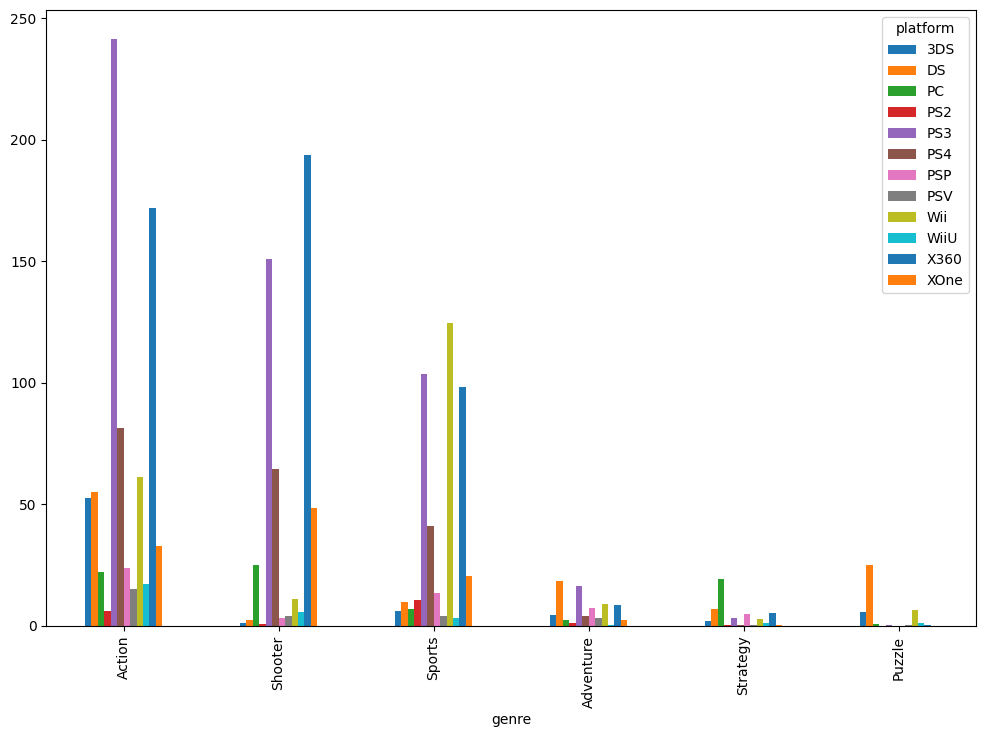

In [65]:
#visualizando
df_filtered_2009_2015_genre_orderedbyts.loc[['Action', 'Shooter', 'Sports', 'Adventure', 'Strategy', 'Puzzle'], '3DS':'XOne'].plot(kind='bar', figsize = (12,8))

In [66]:
df_filtered_2009_2015_platform_biggestsales = (df_filtered_2009_2015_platform.sort_values(ascending=False))

display(df_filtered_2009_2015_platform_biggestsales)

platform
PS3     715.07
X360    669.18
Wii     429.76
PS4     244.89
DS      243.29
3DS     242.67
PC      133.62
XOne    133.17
PSP     101.83
WiiU     77.59
PSV      49.56
PS2      32.49
Name: total_sales, dtype: float64

platform
PS3     715.07
X360    669.18
Wii     429.76
PS4     244.89
DS      243.29
3DS     242.67
PC      133.62
XOne    133.17
PSP     101.83
WiiU     77.59
PSV      49.56
PS2      32.49
Name: total_sales, dtype: float64

<AxesSubplot:xlabel='genre'>

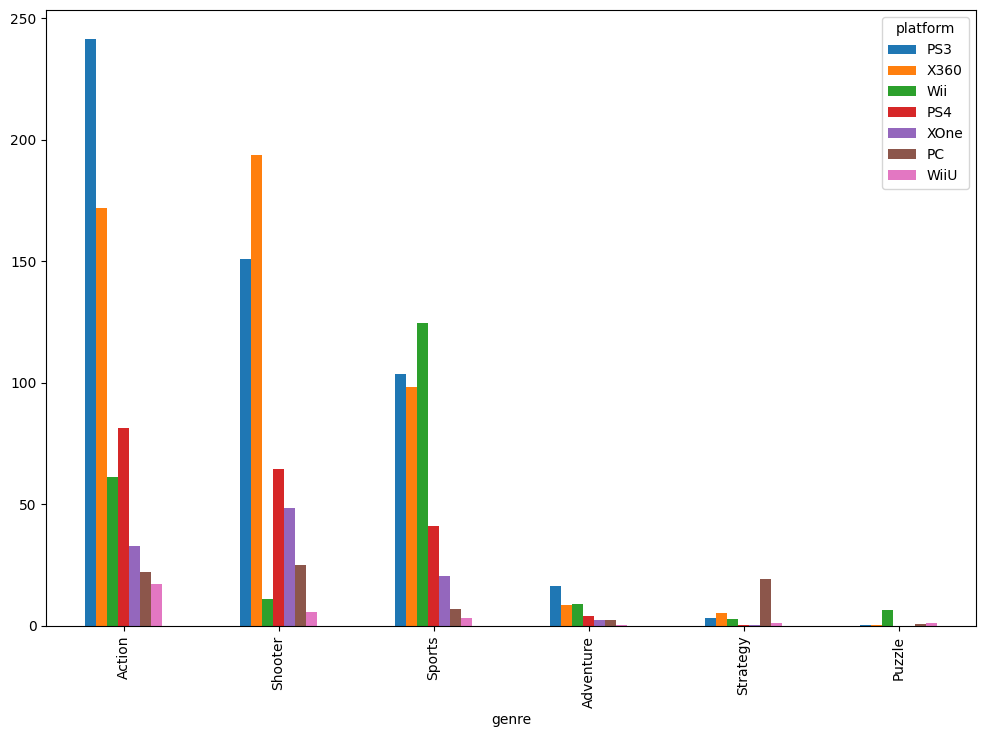

In [67]:
# visualizando plataformas com maiores vendas no período
df_filtered_2009_2015_platform_biggestsales = (df_filtered_2009_2015_platform.sort_values(ascending=False))

display(df_filtered_2009_2015_platform_biggestsales)

# comparando gêneros selecionados entre plataformas selecionadas
(df_filtered_2009_2015_genre_orderedbyts.loc[
    ['Action', 'Shooter', 'Sports', 'Adventure', 'Strategy', 'Puzzle'],
    ['PS3', 'X360', 'Wii', 'PS4', 'XOne', 'PC', 'WiiU']
    ]
    .plot(kind='bar', figsize=(12, 8)))

#### Conclusão preliminar

* Entre todas as plataformas, Action é o gênero com mais vendas, bastante à frente do segundo colocado. Após, vêm: Shooter, Sports, Role-Playing e Misc. Esse top 5 está bem à frente dos demais gêneros.
* Ao olhar por plataforma, percebe-se que algumas puxam mais alguns gêneros que outras. Optou-se por fazer um recorte, dentro do período analisado de 2009 a 2015:
* * dos 3 gêneros com mais vendas e dos três com menos vendas;
* * e do top4 de plataformas com mais vendas gerais no período, somadas ainda as plataformas PC, Wii e WiiU.
  * Com o recorte plotado graficamente, foi possível observar que o elevado total de vendas dos gêneros com mais vendas (Action e Shooter) foi puxado especialmente pelas duas plataformas com mais vendas no período (PS3 e X360).
  * Por outro lado, outras plataformas têm gêneros que desempenham melhor do que Action e Shooter, como é o caso dos gêneros Sports e Puzzle na plataforma Wii ou Strategy na plataforma PC.
  * Assim, não é possível generalizar que Action, Shooter, Sports, Role-Playing e Misc, gêneros que mais vendem no conjunto geral de todas as plataformas, sempre vão desempenhar da mesma forma em cada uma das plataformas. Pelo contrário: os dados mostram que os desempenhos de gênero variam entre as plataformas.


## Perfis regionais de mercado

A análise compara América do Norte, Europa e Japão em três dimensões: plataformas líderes, gêneros mais vendidos e distribuição das classificações ESRB.


In [68]:
display(df_filtered_2009_2015)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales,critic_score,user_score,rating
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,32.77,80.0,8.0,E
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,28.32,87.0,8.4,E
14,Kinect Adventures!,X360,2010,Misc,15.00,4.89,0.24,1.69,21.82,61.0,6.3,E
15,Wii Fit Plus,Wii,2009,Sports,9.01,8.49,2.53,1.77,21.80,80.0,7.4,E
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,21.05,97.0,8.2,M
...,...,...,...,...,...,...,...,...,...,...,...,...
16696,Breach,PC,2011,Shooter,0.01,0.00,0.00,0.00,0.01,61.0,5.8,T
16700,Mezase!! Tsuri Master DS,DS,2009,Sports,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN
16702,STORM: Frontline Nation,PC,2011,Strategy,0.00,0.01,0.00,0.00,0.01,60.0,7.2,E10+
16705,15 Days,PC,2009,Adventure,0.00,0.01,0.00,0.00,0.01,63.0,5.8,NaN


### As cinco plataformas principais. Descreva as variações das suas quotas de mercado de região para região.


In [69]:
# Plataformas top5 região NA
df_filtered_2009_2015__topplatforms_na = df_filtered_2009_2015.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
display(df_filtered_2009_2015__topplatforms_na)

# Total de vendas região NA
total_sales_na = df_filtered_2009_2015['na_sales'].sum()

# Participação percentual de cada plataforma no mercado total da região
share_na = df_filtered_2009_2015__topplatforms_na / total_sales_na * 100
display(share_na)

platform
X360    407.49
PS3     291.23
Wii     235.69
DS      120.61
PS4      87.25
Name: na_sales, dtype: float64

platform
X360    28.675679
PS3     20.494289
Wii     16.585857
DS       8.487506
PS4      6.139913
Name: na_sales, dtype: float64

In [70]:
# Plataformas top5 região EU
df_filtered_2009_2015__topplatforms_eu = df_filtered_2009_2015.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
display(df_filtered_2009_2015__topplatforms_eu)

# Total de vendas região EU
total_sales_eu = df_filtered_2009_2015['eu_sales'].sum()

# Participação percentual de cada plataforma no mercado total da região
share_eu = df_filtered_2009_2015__topplatforms_eu / total_sales_eu * 100
display(share_eu)

platform
PS3     253.74
X360    196.01
Wii     124.11
PS4     109.31
PC       78.79
Name: eu_sales, dtype: float64

platform
PS3     25.946642
X360    20.043357
Wii     12.691092
PS4     11.177692
PC       8.056814
Name: eu_sales, dtype: float64

In [71]:
# Plataformas top5 região JP
df_filtered_2009_2015__topplatforms_jp = df_filtered_2009_2015.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)
display(df_filtered_2009_2015__topplatforms_jp)

# Total de vendas região JP
total_sales_jp = df_filtered_2009_2015['jp_sales'].sum()

# Participação percentual de cada plataforma no mercado total da região
share_jp = df_filtered_2009_2015__topplatforms_jp / total_sales_jp * 100
display(share_jp)

platform
3DS    92.59
PS3    66.99
DS     52.11
PSP    50.39
Wii    34.32
Name: jp_sales, dtype: float64

platform
3DS    26.627746
PS3    19.265501
DS     14.986196
PSP    14.491545
Wii     9.870010
Name: jp_sales, dtype: float64

,Região NA,Região EU,Região JP
platform,,,
3DS,NaN,NaN,26.627746
DS,8.487506,NaN,14.986196
PC,NaN,8.056814,NaN
PS3,20.494289,25.946642,19.265501
PS4,6.139913,11.177692,NaN
PSP,NaN,NaN,14.491545
Wii,16.585857,12.691092,9.870010
X360,28.675679,20.043357,NaN


<AxesSubplot:title={'center':'Percentual do mercado de videogames por região'}, xlabel='Regiões', ylabel='Percentual do mercado'>

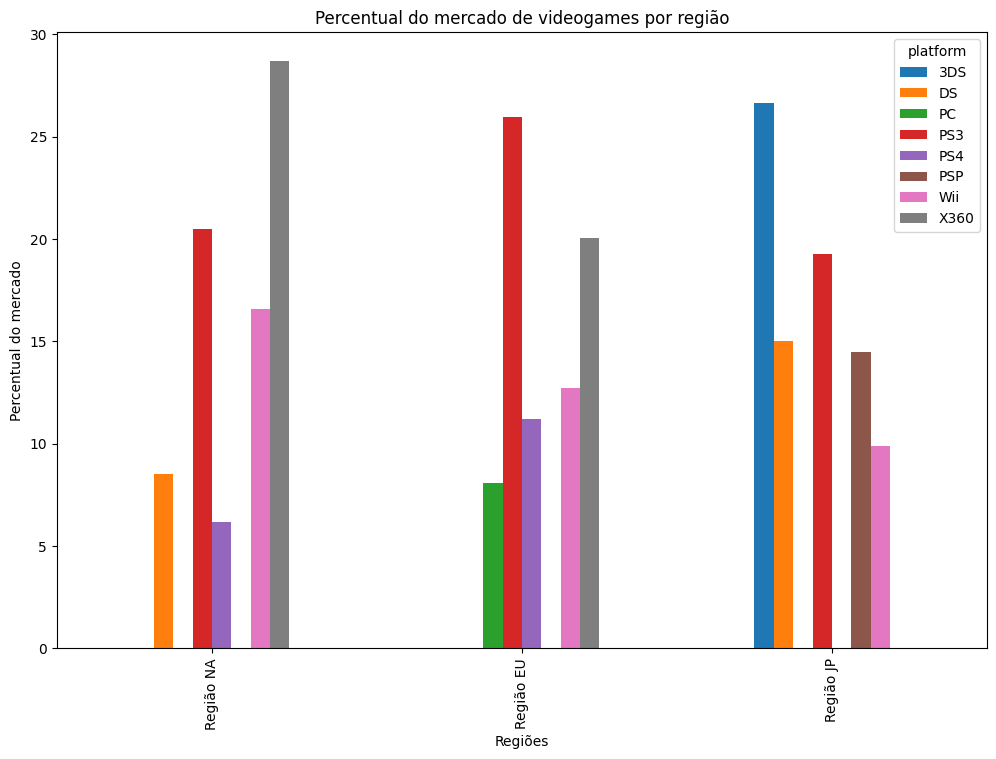

In [72]:
# Comparando participações

df_platform_shares = pd.DataFrame({'Região NA':share_na, 'Região EU': share_eu, 'Região JP': share_jp})
display(df_platform_shares)

df_platform_shares.T.plot(kind='bar', xlabel='Regiões', ylabel='Percentual do mercado', title='Percentual do mercado de videogames por região', figsize=(12,8))

#### Conclusão sobre plataformas principais e variação de quotas de mercado por região (2009-2015)

* **As plataformas top5 por mercado, com respectivas vendas totais, são:**

  _América do Norte_
    - X360: 407.49
    - PS3: 291.23
    - Wii: 235.69
    - DS: 120.61
    - PS4: 87.25

  _Europa_
  - PS3: 253.74
  - X360: 196.01
  - Wii: 124.11
  - PS4: 109.31
  - PC: 78.79

  _Japão_
  - 3DS: 92.59
  - PS3: 66.99
  - DS: 52.11
  - PSP: 50.39
  - Wii: 34.32


* **As plataformas com maior participação percentual no total de vendas por região são:**

    - América do Norte (NA): X360, com 28.6% do mercado local
    - Europa (EU): PS3, com 25.9% do mercado local
    - Japão (JP): 3DS, com 26.6% do mercado local


* **Comparando as quotas de mercado entre as regiões:**

    - X360 tem participação muito maior na América do Norte do que na Europa e é bem menos relevante no Japão.
    - PS3 tem participação forte tanto na Europa quanto na América do Norte, além de aparecer entre as principais no Japão.
    - O Japão é o único dos três mercados em que o 3DS aparece entre as cinco principais plataformas, inclusive liderando o ranking.
    - Wii aparece no top 5 das três regiões, mas com pesos diferentes.
    - PC entra no top 5 europeu, mas não aparece entre as cinco principais de NA ou Japão.
* **Observação de retificação**

* Dado o desempenho do 3DS no mercado japonês, apesar da queda sustentada de vendas da plataforma anteriormente observada, é possível que a plataforma ainda seja suficientemente importante para a Ice.


### Os cinco principais gêneros
Explique a diferença.


In [73]:
# Gêneros top5 região NA
df_filtered_2009_2015__topgenres_na = df_filtered_2009_2015.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
display(df_filtered_2009_2015__topgenres_na)

genre
Action          352.43
Shooter         260.13
Sports          220.12
Misc            163.64
Role-Playing    124.94
Name: na_sales, dtype: float64

In [74]:
# Gêneros top5 região EU
df_filtered_2009_2015__topgenres_eu = df_filtered_2009_2015.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
display(df_filtered_2009_2015__topgenres_eu)

genre
Action          261.23
Shooter         176.40
Sports          146.50
Misc             85.61
Role-Playing     79.28
Name: eu_sales, dtype: float64

In [75]:
# Gêneros top5 região JP
df_filtered_2009_2015__topgenres_jp = df_filtered_2009_2015.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)
display(df_filtered_2009_2015__topgenres_jp)

genre
Role-Playing    114.00
Action           77.09
Misc             29.05
Sports           24.40
Platform         20.54
Name: jp_sales, dtype: float64

,Região NA,Região EU,Região JP
genre,,,
Action,352.43,261.23,77.09
Misc,163.64,85.61,29.05
Platform,NaN,NaN,20.54
Role-Playing,124.94,79.28,114.00
Shooter,260.13,176.40,NaN
Sports,220.12,146.50,24.40


<AxesSubplot:title={'center':'Principais gêneros de videogames por região'}, xlabel='Regiões', ylabel='Percentual do mercado'>

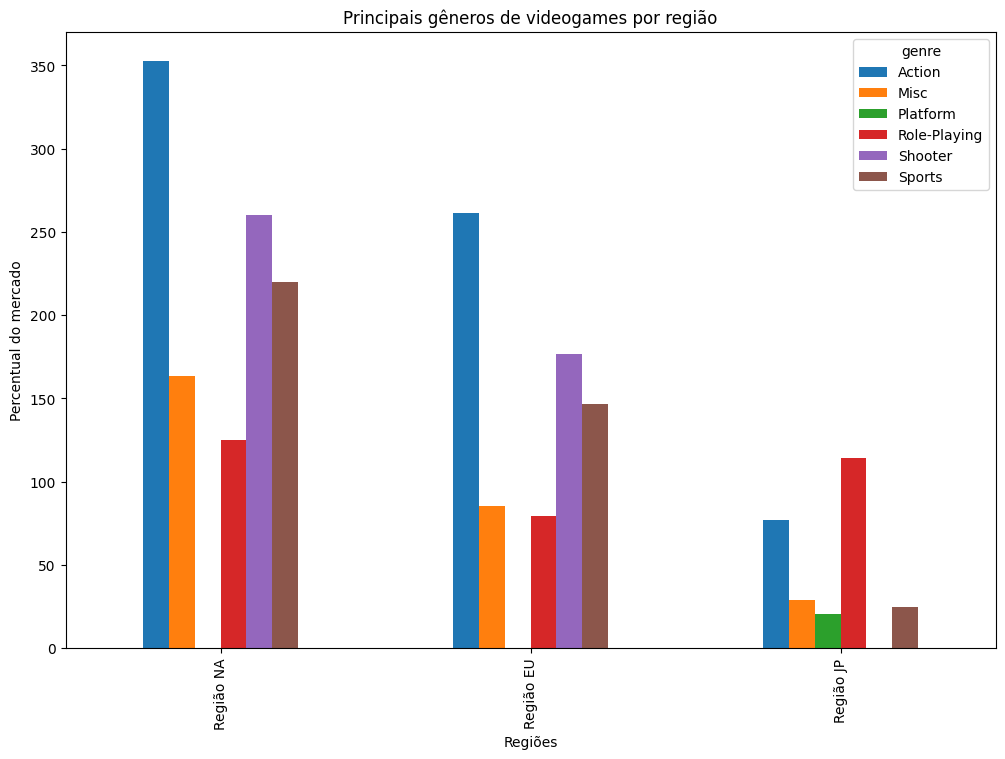

In [76]:
# Gráfico comparativo
df_platform_genres = pd.DataFrame({'Região NA':df_filtered_2009_2015__topgenres_na, 'Região EU': df_filtered_2009_2015__topgenres_eu, 'Região JP': df_filtered_2009_2015__topgenres_jp})
display(df_platform_genres)

df_platform_genres.T.plot(kind='bar', xlabel='Regiões', ylabel='Percentual do mercado', title='Principais gêneros de videogames por região', figsize=(12,8))

#### Conclusão preliminar sobre gêneros

* O top 5 de gêneros mais vendidos nos mercados ocidentais é exatamente igual: Action, Shooter, Sports, Misc e Role-Playing, nessa ordem. Valores diferem um pouco, com o mercado norte-americano vendendo mais, em números absolutos, que o europeu.
* O top 5 japonês é diferente, com uma característica bastante distintiva: o gênero mais vendido é o de Role-Playing, que nos mercados ocidentais é apenas o quarto. E o gênero Shooter sequer entra no top5.
* O 3DS não aparece no top 5 das regiões ocidentais, mas é a plataforma mais vendida no Japão. Ao mesmo tempo, Role-Playing é o gênero líder no mercado japonês, diferentemente dos mercados ocidentais.
* Essa combinação sugere uma possível relação entre o peso dos RPGs no mercado japonês e o sucesso do 3DS na região, mas os dados analisados não são suficientes para estabelecer essa relação causal.


### As classificações do ESRB afetam as vendas em regiões individuais?


In [77]:
# ESRB região NA
df_filtered_2009_2015__topESRB_na = df_filtered_2009_2015.groupby('rating')['na_sales'].sum().sort_values(ascending=False)
display(df_filtered_2009_2015__topESRB_na)

rating
M       425.19
E       395.19
T       218.16
E10+    199.13
EC        1.32
RP        0.00
Name: na_sales, dtype: float64

In [78]:
# ESRB região EU
df_filtered_2009_2015__topESRB_eu = df_filtered_2009_2015.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
display(df_filtered_2009_2015__topESRB_eu)

rating
M       309.96
E       247.89
T       143.49
E10+    117.82
RP        0.03
EC        0.00
Name: eu_sales, dtype: float64

In [79]:
# ESRB região JP
df_filtered_2009_2015__topESRB_jp = df_filtered_2009_2015.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)
display(df_filtered_2009_2015__topESRB_jp)

rating
E       60.42
T       48.32
M       34.43
E10+    20.37
EC       0.00
RP       0.00
Name: jp_sales, dtype: float64

,Região NA,Região EU,Região JP
rating,,,
E,395.19,247.89,60.42
E10+,199.13,117.82,20.37
EC,1.32,0.00,0.00
M,425.19,309.96,34.43
RP,0.00,0.03,0.00
T,218.16,143.49,48.32


<AxesSubplot:title={'center':'Classificação de games por região'}, xlabel='Regiões', ylabel='Percentual do mercado'>

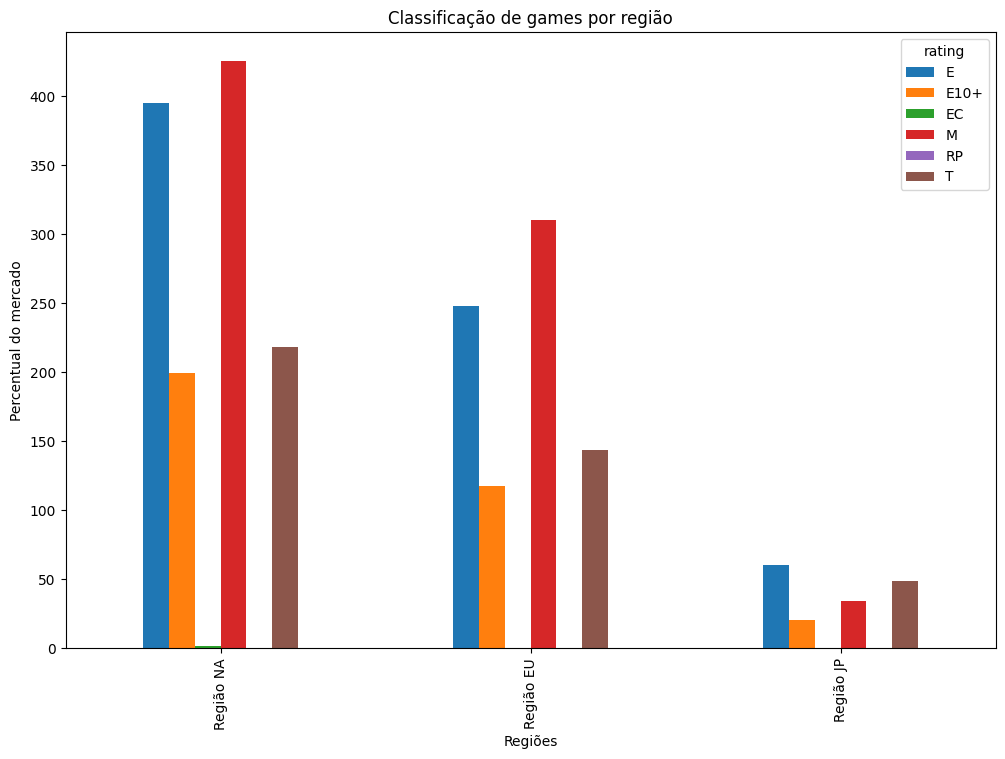

In [80]:
# Gráfico comparativo
df_platform_ESRB = pd.DataFrame({'Região NA':df_filtered_2009_2015__topESRB_na, 'Região EU': df_filtered_2009_2015__topESRB_eu, 'Região JP': df_filtered_2009_2015__topESRB_jp})
display(df_platform_ESRB)

df_platform_ESRB.T.plot(kind='bar', xlabel='Regiões', ylabel='Percentual do mercado', title='Classificação de games por região', figsize=(12,8))

#### Conclusão preliminar sobre classificação etária dos jogos
* Sim, é possível concluir que a classificação etária afeta as vendas por região.
* Enquanto as regiões ocidentais apresentam o mesmo padrão principal de vendas no que diz respeito à classificação etária (M, E, T, E10+), o Japão apresenta um ranking diferente (E, T, M, E10+)
* Essa diferença sinaliza que consumidores de games japoneses são menos propensos a adquirir games com classificação "Mature" (maiores de 17 anos) do que consumidores ocidentais.
* Já consumidores ocidentais aparentam preferir títulos com classificação "Mature".


## Testes de hipótese

São avaliadas duas questões:
- se as avaliações médias de usuários de Xbox One e PC diferem;
- se as avaliações médias dos gêneros Action e Sports diferem.

Em ambos os testes é usado nível de significância de 5%.


### Hipótese: As classificações médias dos usuários das plataformas Xbox One e PC são as mesmas


#### H0: As classificações médias dos usuários das plataformas Xbox One e PC são as mesmas.


In [81]:
# calculando média do conjunto completo para conhecimento
series_platform_mean_test = df_filtered_2009_2015.groupby('platform')['user_score'].mean()

#montando conjuntos de dados para o teste

## avaliações XOne
xone_user_scores_series = df_filtered_2009_2015[df_filtered_2009_2015['platform'] == 'XOne']['user_score']
###checando tamanho
xone_user_scores_series.shape
###checando nulos
xone_user_scores_series.isna().sum()
###retirando nulos
xone_user_scores_series = xone_user_scores_series.dropna()
###conferindo
xone_user_scores_series.shape
xone_user_scores_series.isna().sum()

## avaliações PC
pc_user_scores_series = df_filtered_2009_2015[df_filtered_2009_2015['platform'] == 'PC']['user_score']
###checando tamanho
pc_user_scores_series.shape
###checando nulos
pc_user_scores_series.isna().sum()
###retirando nulos
pc_user_scores_series = pc_user_scores_series.dropna()
###conferindo
pc_user_scores_series.shape
pc_user_scores_series.isna().sum()


0

In [82]:
# realizando teste estatístico

# teste com alpha 0.05
alpha = 0.05

results = st.ttest_ind(xone_user_scores_series, pc_user_scores_series, equal_var=False)

display(results.pvalue)

if results.pvalue < alpha:
	print("Rejeitamos a hipótese nula")
else:
	print("Não podemos rejeitar a hipótese nula")

0.1203835791163738

Não podemos rejeitar a hipótese nula


#### Resultado: Xbox One × PC

O teste avalia como hipótese nula a igualdade entre as médias de avaliação dos usuários de Xbox One e PC. Com `alpha = 0,05`, o valor-p obtido foi aproximadamente 0,12.

Como o valor-p é superior ao nível de significância, **não rejeitamos a hipótese nula**. Isso significa que, com os dados disponíveis, não há evidência estatística suficiente para afirmar que as médias de avaliação das duas plataformas sejam diferentes.


### Hipótese: As classificações médias de usuários para os gêneros Action (ação) e Sports (esportes) são diferentes.


#### H0: As classificações médias de usuários para os gêneros Action (ação) e Sports (esportes) são as mesmas.


In [83]:
# calculando média do conjunto completo para conhecimento
series_genres_mean_test = df_filtered_2009_2015.groupby('genre')['user_score'].mean()

#montando conjuntos de dados para o teste

## avaliações Action games
action_user_scores_series = df_filtered_2009_2015[df_filtered_2009_2015['genre'] == 'Action']['user_score']
###checando tamanho
action_user_scores_series.shape
###checando nulos
action_user_scores_series.isna().sum()
###retirando nulos
action_user_scores_series = action_user_scores_series.dropna()
###conferindo
action_user_scores_series.shape
action_user_scores_series.isna().sum()


## avaliações Sports games
sports_user_scores_series = df_filtered_2009_2015[df_filtered_2009_2015['genre'] == 'Sports']['user_score']
###checando tamanho
display(sports_user_scores_series.shape)
###checando nulos
sports_user_scores_series.isna().sum()
###retirando nulos
sports_user_scores_series = sports_user_scores_series.dropna()
###conferindo
sports_user_scores_series.shape
sports_user_scores_series.isna().sum()


(710,)

0

In [84]:
# realizando teste estatístico

alpha = 0.05

results = st.ttest_ind(action_user_scores_series, sports_user_scores_series, equal_var=False)

print(results.pvalue)

if results.pvalue < alpha:
    print('Rejeitamos a hipótese nula')
else:
    print('Não rejeitamos a hipótese nula')

5.582886045062175e-09
Rejeitamos a hipótese nula


#### Resultado: Action × Sports

A hipótese nula considera iguais as médias de avaliação dos usuários para os gêneros Action e Sports; a hipótese alternativa considera que elas diferem.

O valor-p foi aproximadamente `5,58e-09`, muito inferior a `alpha = 0,05`. Portanto, **rejeitamos a hipótese nula** e encontramos evidência estatística de diferença entre as médias de avaliação dos dois gêneros.


### Critério dos testes

Nos dois casos, a hipótese nula representa igualdade entre as médias e a hipótese alternativa representa diferença. Foi adotado nível de significância de 5%, valor convencional para esse tipo de teste.


## Conclusões e recomendações


## Conclusão final
O projeto visou analisar dados sobre games e plataformas de games para planejar o ano de 2017. Imaginou-se estar em dezembro de 2016. O conjunto de dados reuniu um conjunto de informações sobre 16715 games (alguns repetidos em diferentes plataformas), abrangendo o período de 1980 a 2016, com a ressalva de que os dados de 2016 estariam incompletos.
Os dados tinham alguns problemas iniciais, como nomes das colunas não padronizados e alguns tipos de dados não pertinentes. Foram resolvidos. Percebi casualmente um valor ilógico para um game de DS. Corrigi.

Na análise de dados, percebeu-se que:

* O período 1980-2016 apresentou quatro momentos distintos no que diz respeito à quantidade de games lançada:  1980-1993: poucos jogos lançados (menos de 100 por ano); 1994-2009: começa a superar 100 anuais e entra numa tendência geral de crescimento até os auges do conjunto de dados, de 2008 e 2009 (1427 e 1426 jogos anuais, respectivamente); 2010-2012: produção de jogos decai rapidamente; 2013-2016:  após decaimento rápido entre 2010 e 2012, estabiliza em patamar médio de 500 a 700 anuais.
* As plataformas com maiores vendas no período completo foram, na ordem: PS2, X360, PS3, Wii, DS e PS.Entre as com mais vendas, DS, PS e PS2 já foram populares, mas nos anos recentes (2014-2016) já não vendem mais.Concluiu-se que o ciclo de vida típico de uma plataforma é de 7 a 8 anos. Essa estimativa é com a manutenção da plataforma PC na análise; sem ela, o ciclo típico máximo é de até 7,5 anos. A plataforma PC tem um comportamento singular, dado que permanece com vendas ativas desde 1980.
* Após esta análise inicial, foi realizado um recorte no conjunto de dados completo, para fins de construir informações para a campanha de 2017. A partir do ciclo de vida típico de 7 a 8 anos, optou-se por trabalhar com dados que vão de 2009 a 2015. O ano de 2016 foi desconsiderado por ter informações incompletas e potencialmente gerar distorções nas análises sem que pudesse haver algum ganho real). Entende-se que uma janela de sete anos permite observar aproximadamente um ciclo típico de mercado, ao mesmo tempo em que prioriza dados recentes para a construção de um modelo voltado a 2017.

**A partir daqui, salvo indicação expressa, os dados sempre se referem ao período 2009-2015.**
* No novo recorte, constatou-se que PS3, X360, Wii, PS4, DS e 3DS compõem o top6 de vendas totais.
* Utilizando-se como parâmetro o recorte 2013-2015 para analisar tendência de vendas, PS4 e XOne mostram crescimento sustentado, definido por crescimento sucessivo ano a ano. De forma análoga, 3DS, PS3, PSP e X360 mostram queda sustentada.  PC, WiiU e PSV oscilam no período, e DS aparenta ter chegado ao fim de seu ciclo de vida, pois não têm vendas em nenhum dos 3 anos.
* Dessa última análise, concluiu-se que PS4, XOne, PC e WiiU são plataformas ainda potencialmente lucrativas, por diferentes motivos. PS4 e XOne por apresentarem crescimento sustentado, PC por manter-se ativa ao longo de todo o período (portanto jogos para a plataforma sempre poderão fazer sucesso) e WiiU por oscilar, mas manter um bom nível de vendas ainda em 2015.

**Demais conclusões do conjunto de dados:**
* Wii, X360 e PS3 têm os games de maior sucesso de vendas no período analisado.
* PS4, XOne, X360 e PS3, nessa ordem, foram as plataformas cujos jogos lançados mais rendem, em média, para as empresas (lembrando que X360 e PS3 já têm ciclo de vida encerrado em 2015)
* PS3, X360, PS4 e Wii são as plataformas que tiveram maior renda média anual no período analisado. E Wii, no período analisado, é a plataforma que lançou os maiores sucessos de vendas dentre todas.
* Jogos em PS4 vendem consistentemente mais do que quando também são lançados por outra plataforma. Porém, há uma exceção importante na comparação desta com WiiU: enquanto 26 jogos para PS4 venderam mais, outros 11 para WiiU venderam mais, mostrando proximidade de desempenho entre ambas. Ressalta-se, porém, que o conjunto de jogos lançados para ambas plataformas é muito menor do que nas demais comparações.
* Na comparação de PS4 com a plataforma que parece ser sua principal concorrente, a XOne: 202 jogos lançados para PS4 e XOne venderam mais no PS4, e apenas 7 venderam mais no XOne.
* Não existe correlação entre avaliações de usuários e vendas totais, mas existe uma pequena correlação positiva entre avaliações os críticos e vendas totais.
* Entre todas as plataformas, Action é o gênero com mais vendas, bastante à frente do segundo colocado. Após, vêm: Shooter, Sports, Role-Playing e Misc. Esse top 5 está bem à frente dos demais gêneros.
* O elevado total de vendas dos gêneros com mais vendas (Action e Shooter) foi puxado especialmente pelas duas plataformas com mais vendas no período (PS3 e X360).
* Por outro lado, outras plataformas têm gêneros que desempenham melhor do que Action e Shooter, como é o caso dos gêneros Sports e Puzzle na plataforma Wii ou Strategy na plataforma PC.
* Assim, não é possível generalizar que Action, Shooter, Sports, Role-Playing e Misc, gêneros que mais vendem no conjunto geral de todas as plataformas, sempre vão desempenhar da mesma forma em cada uma das plataformas. Pelo contrário: os dados mostram que os desempenhos de gênero variam entre as plataformas.

**A seguir, construíram-se comparações entre as três regiões: NA, EU e JP (América do Norte, Europa e Japão). Concluiu-se que:**
* As plataformas líderes variaram bastante entre as regiões. Na América do Norte, o X360 teve o maior volume de vendas, seguido por PS3 e Wii. Na Europa, o PS3 liderou, com X360 em segundo lugar. Já no Japão, o mercado apresentou um perfil diferente, com o 3DS na liderança, seguido por PS3 e DS. Essas diferenças mostram que a importância relativa das plataformas não foi igual nos três mercados.
* As plataformas com maior participação percentual no total de vendas por região são: X360 na América do Norte (NA), com 28.6% do mercado local; PS3 na     Europa (EU:, com 25.9% do mercado local; 3DS no Japão (JP), com 26.6% do mercado local.
* Comparativamente entre as regiões, X360 tem participação muito maior na América do Norte do que na Europa e é bem menos relevante no Japão. Já PS3 tem participação forte tanto na Europa quanto na América do Norte, além de aparecer entre as principais no Japão. Por fim, o Japão é o único dos três mercados em que o 3DS aparece entre as cinco principais plataformas, inclusive liderando o ranking.
* Nos mercados ocidentais, o ranking de gêneros é igual e liderado por Action, enquanto o Japão se destaca pela liderança de Role-Playing e pela ausência de Shooter no top 5. Esse perfil pode estar relacionado ao sucesso do 3DS no Japão, embora os dados não permitam afirmar causalidade.
* As regiões ocidentais apresentam maior peso de jogos classificados como Mature, enquanto no Japão predominam títulos E e T, indicando diferenças regionais no padrão de vendas por classificação etária.
**Por fim, foram testadas duas hipóteses:**
* Se as classificações médias dos usuários das plataformas Xbox One e PC são as mesmas.
* Se as classificações médias de usuários para os gêneros Action (ação) e Sports (esportes) são diferentes.
* No teste entre Xbox One e PC, não houve evidência suficiente para concluir que as avaliações médias dos usuários diferem. Já no teste entre Action e Sports, a hipótese nula de igualdade foi rejeitada, indicando diferença estatisticamente significativa entre as médias.

### Recomendações para campanha de 2017 da loja Ice com base na análise de dados
* Deve-se investir prioritariamente nas plataformas PS4 e XOne, pois estas apresentam crescimento sustentado nos anos mais recentes e aparentam estar em seu início/meio de ciclo de vida, enquanto demais plataformas já caminham para seu fim. Além disso, elas lançam os jogos mais rentáveis.
* Entre as duas, recomenda-se especial foco no PS4, pois na comparação direta com sua principal concorrente aparente, XOne, os jogos para PS4 quase sempre venderam mais que os mesmos jogos em XOne (202 contra 7 entre 2009-2015).
* A indicação sobre o investimento prioritário nas plataformas PS4 e XOne é especialmente para os mercados NA e EU, onde parece claro que as vendas dessas plataformas tendem a crescer.
* No mercado japonês, a indicação sobre investir nas plataformas PS4 e XOne permanece devido a sua tendência de crescimento, mas a indicação tem menos ênfase do que nos outros mercados porque o 3DS é a plataforma mais vendida do país e ainda mantém um número significativo de vendas em 2015, apesar da queda sustentada observada ao longo dos últimos anos.
* Além disso, o mercado japonês tem um perfil distinto, privilegiando games de Role-playing em comparação com quaisquer outros gêneros, bem como privilegiando games de classificação livre. Como pôde-se concluir da análise, é possível que as plataformas contribuam para o ranking de gêneros mais vendidos e, como a plataforma 3DS é a mais vendida do Japão, entende-se que essas características possam ser indicativo de que consumidores japoneses ainda tendem a querer comprar jogos da plataforma.
* Outras duas plataformas que merecem atenção, em um bloco inferior às já citadas, são WiiU e PC.
* WiiU porque ainda não chegou a seu fim de ciclo, tendo bons números ainda em 2015, e porque é a única plataforma que compete com PS4 em relação a jogos lançados simultaneamente para ambas.
* PC porque se mantém ativa há décadas, além de ser a única plataforma onde o gênero Strategy lidera as vendas (e por uma boa margem). Portanto, jogos desse gênero tendem a fazer sucesso com PC.
* As avaliações de críticos apresentam pequena correlação positiva com vendas e podem servir como um sinal complementar na seleção de títulos. A análise, porém, não permite afirmar que avaliações mais altas causem maiores vendas.
* Do ponto de vista dos gêneros, sugere-se o investimento em gêneros de Action e Shooter para os mercados NA e EU, e em jogos role-playing para o mercado japonês. Tanto pelas características dos mercados como por consequência das recomendações sobre as plataformas, dado que PS4 e XOne, fortemente recomendados para o mercado europeu, tendem a vender mais jogos de Action e Shooter, enquanto o 3DS, recomendado especificamente para o mercado japonês, tende a vender mais jogos de role-playing. 
